Se comparan dos métodos de extracción de características, espectral clásico (FFT/PSD) y tiempo-frecuencia (STFT/wavelets), con el mismo clasificador (SVM RBF), las mismas ventanas y los mismos folds. Las ventanas se agrupan por archivo para evitar fuga de información por el solape.

In [7]:
import sys
sys.path.append('../')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.caracteristicas import conjuntos_de_features
from src.modelos import comparar, resumen, curvas_roc

df_feat = pd.read_csv('../data/processed/features.csv')
cols_feat = [c for c in df_feat.columns if c.startswith(('est_', 'psd_', 'wav_', 'stft_'))]
X = df_feat[cols_feat]
y = df_feat['etiqueta'].values
grupos = df_feat['archivo'].values      # todas las ventanas de un mismo registro van al mismo fold

todos = conjuntos_de_features(cols_feat)
conjuntos = {k: todos[k] for k in ['B_espectral_clasico', 'C_tiempo_frecuencia']}

print({k: len(v) for k, v in conjuntos.items()})
print('Crisis:', y.sum(), '| No crisis:', (y == 0).sum(), '| Archivos:', len(np.unique(grupos)))

{'B_espectral_clasico': 23, 'C_tiempo_frecuencia': 40}
Crisis: 1000 | No crisis: 4000 | Archivos: 500


In [10]:
res = comparar(X, y, grupos, conjuntos, n_splits=5, semilla=0)
res.to_csv('../data/processed/resultados_fase5.csv', index=False)
resumen(res)

,sensibilidad,especificidad,f1,auc
conjunto,,,,
B_espectral_clasico,0.963 ± 0.034,0.982 ± 0.016,0.947 ± 0.034,0.995 ± 0.006
C_tiempo_frecuencia,0.977 ± 0.02,0.988 ± 0.011,0.964 ± 0.03,0.997 ± 0.004


In [11]:
import sys
sys.path.append('../')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.caracteristicas import calcular_psd, calcular_stft, calcular_wavelet, FS

os.makedirs('../figuras', exist_ok=True)

In [14]:
res.round(3)

,fold,conjunto,sensibilidad,especificidad,f1,auc
0,0,B_espectral_clasico,0.975,0.966,0.924,0.993
1,0,C_tiempo_frecuencia,0.965,0.978,0.939,0.996
2,1,B_espectral_clasico,0.925,0.999,0.959,0.999
3,1,C_tiempo_frecuencia,0.980,0.999,0.987,1.000
4,2,B_espectral_clasico,1.000,1.000,1.000,1.000
5,2,C_tiempo_frecuencia,1.000,1.000,1.000,1.000
6,3,B_espectral_clasico,0.985,0.969,0.934,0.999
7,3,C_tiempo_frecuencia,0.990,0.985,0.966,0.999
8,4,B_espectral_clasico,0.930,0.975,0.916,0.985
9,4,C_tiempo_frecuencia,0.950,0.976,0.929,0.992


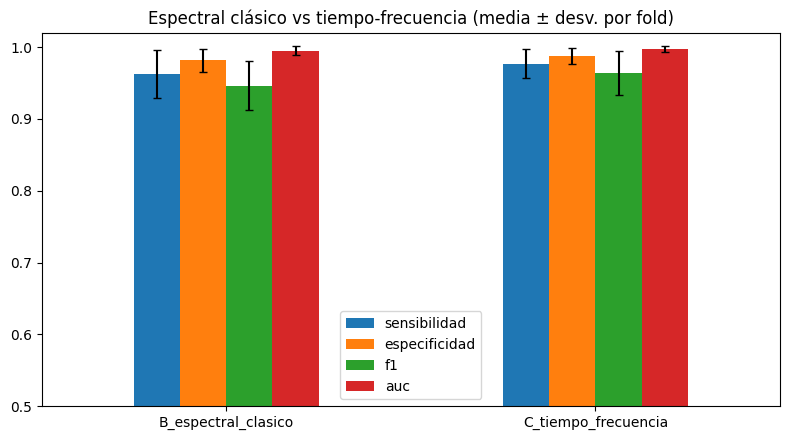

In [15]:
metricas = ['sensibilidad', 'especificidad', 'f1', 'auc']
t = res.groupby('conjunto')[metricas]
t.mean().plot(kind='bar', yerr=t.std(), capsize=3, rot=0, figsize=(8, 4.5))
plt.ylim(0.5, 1.02); plt.xlabel(''); plt.title('Espectral clásico vs tiempo-frecuencia (media ± desv. por fold)')
plt.tight_layout(); plt.show()

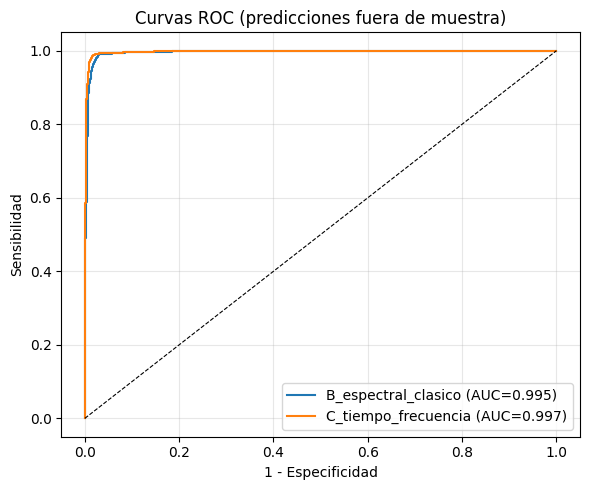

In [16]:
roc = curvas_roc(X, y, grupos, conjuntos, semilla=0)
plt.figure(figsize=(6, 5))
for nombre, (fpr, tpr, auc) in roc.items():
    plt.plot(fpr, tpr, label=f'{nombre} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=0.8)
plt.xlabel('1 - Especificidad'); plt.ylabel('Sensibilidad')
plt.title('Curvas ROC (predicciones fuera de muestra)'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

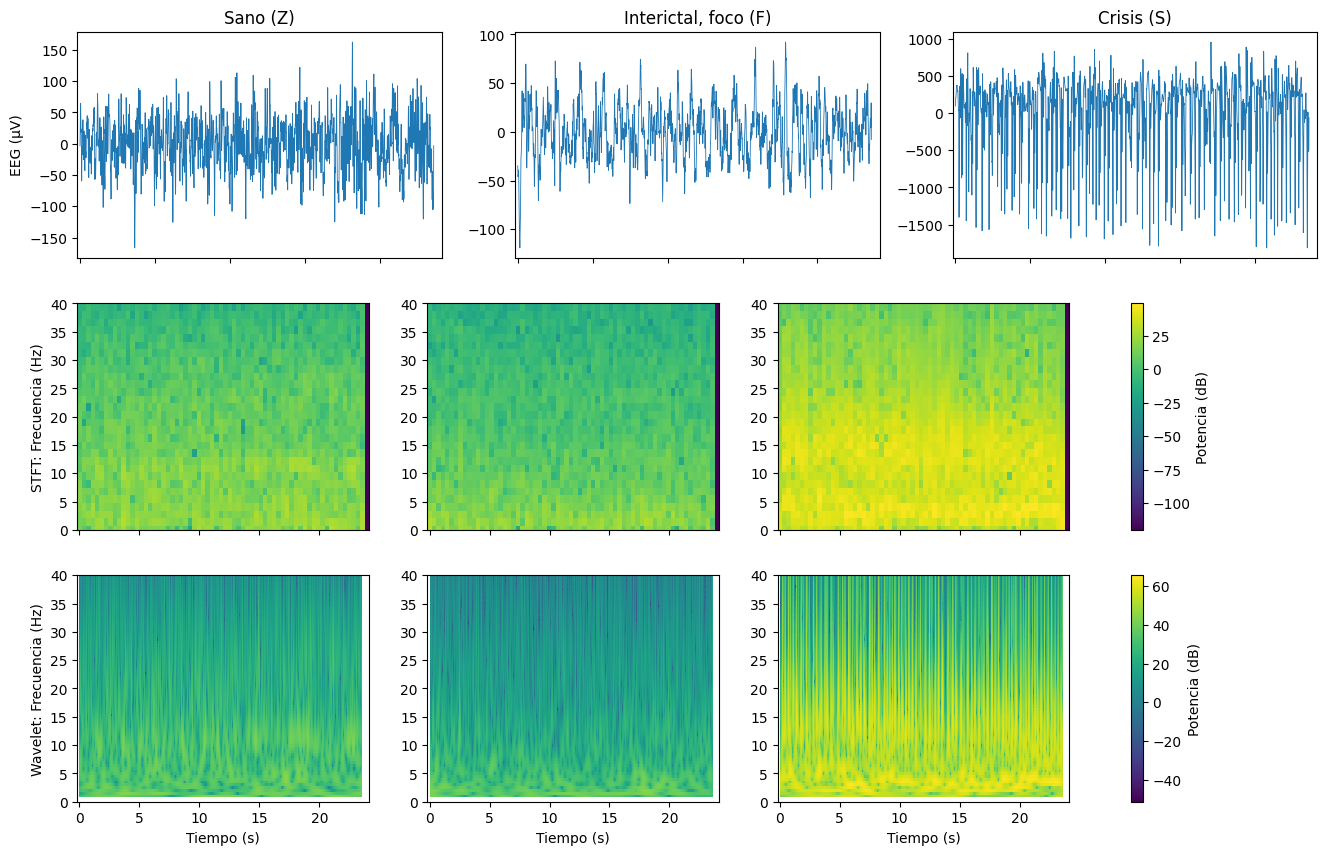

In [14]:
from src.dataset import cargar_dataset_completo
from src.preprocesamiento import filtrar_senal

df_raw = cargar_dataset_completo('../data/raw/')
clases = {'Sano (Z)': 'Z', 'Interictal, foco (F)': 'F', 'Crisis (S)': 'S'}
senales = {n: filtrar_senal(df_raw[df_raw.carpeta_original == c].iloc[0]['senal']) for n, c in clases.items()}
t = np.arange(len(next(iter(senales.values())))) / FS

esp = {}
for n, x in senales.items():
    f, tt, P = calcular_stft(x)
    fw, Pw = calcular_wavelet(x)
    esp[n] = (10*np.log10(P + 1e-12), f, tt, 10*np.log10(Pw + 1e-12), fw)
vs = (min(v[0].min() for v in esp.values()), max(v[0].max() for v in esp.values()))
vw = (min(v[3].min() for v in esp.values()), max(v[3].max() for v in esp.values()))

fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)
for j, (n, x) in enumerate(senales.items()):
    S, f, tt, W, fw = esp[n]
    o = np.argsort(fw)
    axes[0, j].plot(t, x, lw=0.6); axes[0, j].set_title(n)
    im1 = axes[1, j].pcolormesh(tt, f, S, shading='auto', vmin=vs[0], vmax=vs[1]); axes[1, j].set_ylim(0, 40)
    im2 = axes[2, j].pcolormesh(t, fw[o], W[o], shading='auto', vmin=vw[0], vmax=vw[1]); axes[2, j].set_ylim(0, 40)
    axes[2, j].set_xlabel('Tiempo (s)')
axes[0, 0].set_ylabel('EEG (µV)'); axes[1, 0].set_ylabel('STFT: Frecuencia (Hz)'); axes[2, 0].set_ylabel('Wavelet: Frecuencia (Hz)')
fig.colorbar(im1, ax=axes[1, :], label='Potencia (dB)'); fig.colorbar(im2, ax=axes[2, :], label='Potencia (dB)')
plt.savefig('../figuras/tres_clases_2d.png', dpi=200, bbox_inches='tight')
plt.show()